# Optimización multiobjetivo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from numpy.linalg import norm
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings("ignore")

# 1. Importación de elementos

In [2]:
def visualizar_RS(df_sel):
    y_test = df_sel['SSPL']
    y_pred = df_sel['SSPL_pred']

    # Asume que ya tienes: y_test (Series), y_pred (array-like), pred_obj (float)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")

    plt.xlabel("SSPL real")
    plt.ylabel("SSPL predicho")
    plt.title("Predicción vs Realidad")
    plt.tight_layout()
    plt.show()

# 2. Carga de datos y revisión básica de calidad

Para la implementación de FUCO en primer lugar es necesario realizar la carga del conjunto de datos. En este caso, se hace uso del conjunto de datos *AirfoilSelfNoise.csv* l cual es un conjunto de datos de la NASA obtenido a partir de una seri de pruebas aerodinámicas y acústicas de secciones de álabes aerodinámicos bidimensionales y tridimensionales, realizadas en un túnel de viento anecoico.  Es por esto que se pasa a realizar la carga del conjuto de datos en el entorno:

In [3]:
# Se realiza la carga de los datos
df = pd.read_csv("AirfoilSelfNoise.csv", sep=',')

# 3. Modelado

Como paso previo a la implementación de FUCO, es necesario tener un modelo de regresión en el entorno. En esta implementación se ha obtado por entrenar un modelo de regresión lineal que se encargue de predección la variable **SSPL** a partir del resto de variables existentes en el conjunto de datos. Para esta implementación se ha decidido no optimizar mediante hiperparámetros el modelo ya que esta implementación no busca rendimiento sino la capacidad de mostrar la implementación y funcionamiento del framework. Se pasa a realizar el entrenamiento del modelo:

Intercepto: 132.5315974058017

Coeficientes:
f              -0.001272
alpha          -0.405660
c             -34.469438
U_infinity      0.098021
delta        -139.460274
dtype: float64
----------------------------------------------------
MSE: 22.128643318247306
R²: 0.5582979754897279
----------------------------------------------------


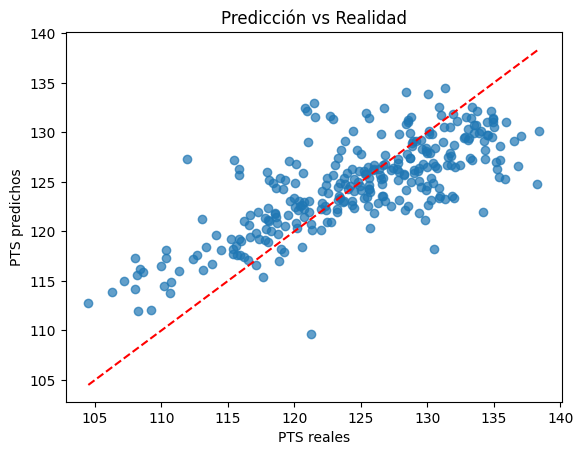

In [4]:
# Selección de variables 
X = df.drop(columns=["SSPL"])
y = df["SSPL"]

# División en conjunto de train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creación y entrenamiento del modelo
modelo_no_t_bl = LinearRegression()
modelo_no_t_bl.fit(X_train, y_train)

# Predicciones
y_pred = modelo_no_t_bl.predict(X_test)

# Evaluación del modelo
coeficientes = pd.Series(modelo_no_t_bl.coef_, index=X_train.columns)
print("Intercepto:", modelo_no_t_bl.intercept_)
print("\nCoeficientes:")
print(coeficientes)

# Cálculo de error cuadrátrico y R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("----------------------------------------------------")
print("MSE:", mse)
print("R²:", r2)
print("----------------------------------------------------")

plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("PTS reales")
plt.ylabel("PTS predichos")
plt.title("Predicción vs Realidad")
plt.show()

# 4. FUCO

A través de este apartado, se realiza la implementación de FUCO. Para ello, en primer lugar, se realiza la división del espacio de respuesta a partir del la observación fáctica seleccionada y los umbrales de epsilon y delta definidos. Posteriormente, se realiza la generación de las alteración de la observación que en este caso serán mediante **Optimización multiobjetivo**. Estas alteraciónes de la observación será evaluadas mediante diferentes propiedades para comprobar cuales de ellas son las mejores para construir explicaciones contrafácticas. Por último, se realizará la construcción de las explicaciones.

## 4.1 División del espacio de respuesta

Como primer paso se realiza la divisón del espacio de respuesta. Para ello, es necesario seleccionar una observación a analizar la cual en nuestro caso es la 1487. Posteriormente, se definen los umbrales y se realiza el filtrado del conjunto de datos para la construcción de los Response sets:

In [5]:
# Se calcula las predicciones del modelo para los regisros
df['SSPL_pred'] = modelo_no_t_bl.predict(X)

# Se selecciona el resgistro objetivo sobre el que se calcularan los contrafácticos
print("----------- OBSERVACIÓN ORIGINAL -----------")
pred_obj = 123.514
print(df[df['SSPL']==pred_obj])

# Se definen los umbrales de epsilon y delta que dividiran el espacio de respuesta
epsilon_u_y = pred_obj + 2 
epsilon_l_y = pred_obj - 2 
delta_u_y = pred_obj + 6 
delta_l_y = pred_obj - 6 

# Se divide el espacio de respuesta
df_RF = df[(df['SSPL_pred'] <=epsilon_u_y) & (df['SSPL_pred'] >= epsilon_l_y)].reset_index().drop('index',axis=1) 
df_RCF = df[((df['SSPL_pred'] >=epsilon_u_y) & (df['SSPL_pred'] <= delta_u_y)) | ((df['SSPL_pred'] <=epsilon_l_y) & (df['SSPL_pred'] >= delta_l_y))].reset_index().drop('index',axis=1)
df_FCF = df[(df['SSPL_pred'] >=epsilon_u_y) | (df['SSPL_pred'] <= epsilon_l_y)].reset_index().drop('index',axis=1) 

----------- OBSERVACIÓN ORIGINAL -----------
        f  alpha       c  U_infinity     delta     SSPL   SSPL_pred
1487  200   15.6  0.1016        39.6  0.052849  123.514  118.958208


Se realiza la visualización de la división del espacio de respuesta:

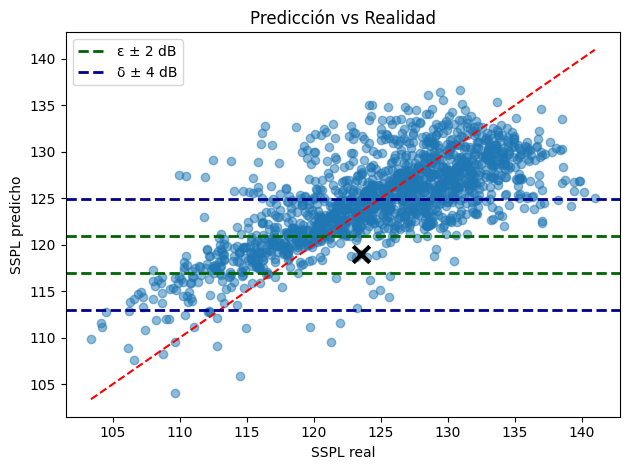

In [6]:
y_test = df['SSPL']
y_pred = df['SSPL_pred']

# Asume que ya tienes: y_test (Series), y_pred (array-like), pred_obj (float)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
y_pred_arr = np.asarray(y_pred)
i = df[df['SSPL']==pred_obj].index[0]

x_obj = y_test.iloc[i]      # SSPL real correspondiente
y_obj = y_pred_arr[i]       # SSPL predicho (cerca de pred_obj)

# Se definen los umbrales de epsilon y delta que dividiran el espacio de respuesta
epsilon_u_y = y_obj + 2 
epsilon_l_y = y_obj - 2 
delta_u_y = y_obj + 6 
delta_l_y = y_obj - 6 

plt.scatter([x_obj], [y_obj], marker="x", s=140, linewidths=3, color = 'black')

# Colores distintos
epsilon_color = "darkgreen"
delta_color   = "darkblue"

plt.axhline(y=epsilon_u_y, linestyle="--", linewidth=2, color=epsilon_color, label="ε ± 2 dB")
plt.axhline(y=epsilon_l_y, linestyle="--", linewidth=2, color=epsilon_color)

plt.axhline(y=delta_u_y, linestyle="--", linewidth=2, color=delta_color, label="δ ± 4 dB")
plt.axhline(y=delta_l_y, linestyle="--", linewidth=2, color=delta_color)

plt.xlabel("SSPL real")
plt.ylabel("SSPL predicho")
plt.title("Predicción vs Realidad")
plt.legend()
plt.tight_layout()
plt.show()


## 4.2 Generación de observaciones candidatas

Para la generación de las observaciones candidatas, en este caso se ha seleccionado el método de *Optimización multiobjetivo*. Este método aborda la generación de contrafácticos como un problema de optimización en el que deben satisfacerse simultáneamente varios objetivos, como minimizar la distancia con la observación original, garantizar la plausibilidad de los cambios y respetar las restricciones definidas por los stakeholders.

Adicionalmente en esta sección, se realiza la construcción de las métricas de evaluación. En nuestro caso para FUCO han sido selecciónadas la validez, la proximidad, la robustez y la plausbilidad. Con estas variables se puede conocer a las alteraciones de la observación desde diferentes puntos de vista.

### 4.2.1 Preparación del entorno

In [7]:
# 1º CREACIÓN DE OBSERVACIONES: Se generan las observaciones alteradas a partir de la observación factual
# Instancia factual:
df_factual = df[df['SSPL']==pred_obj].copy()
print("----------- OBSERVACIÓN FACTICA -----------")
print(df_factual)

# Definición del entorno
x_factual = df_factual.iloc[0]  # vector de referencia
accionables = ['f', 'alpha', 'c', 'U_infinity', 'delta']
inmutables = []  # si hay alguna, por ejemplo 'age', 'gender', etc.

# Entrenamiento previo del modelo KNN sobre datos reales
real_data = df[accionables]
knn_model = NearestNeighbors(n_neighbors=5)
knn_model.fit(real_data)

# Factual vector para calcular proximidad
x_factual_vector = x_factual[accionables].values

----------- OBSERVACIÓN FACTICA -----------
        f  alpha       c  U_infinity     delta     SSPL   SSPL_pred
1487  200   15.6  0.1016        39.6  0.052849  123.514  118.958208


### 4.2.2 Definición de funciones

In [8]:
# Función 1: Proximidad L1
def objective_proximidad_L1(x_prime):
    return norm(x_prime - x_factual_vector, ord=1)

# Función 2: Plausibilidad basada en KNN
def objective_plausibilidad_knn(x_prime):
    x_prime_2d = np.array(x_prime).reshape(1, -1)
    distances, _ = knn_model.kneighbors(x_prime_2d)
    return distances.mean()

# Función 3: Robustez
def objective_robustez(x_prime, model=modelo_no_t_bl, n_perturb=5, noise=0.01):
    perturbations = np.array([
        x_prime + np.random.normal(0, noise, size=len(x_prime))
        for _ in range(n_perturb)
    ])
    preds = model.predict(perturbations)
    return np.std(preds)

# Función 4: Comprueba si la predicción se encuentra dentro de RCF
def is_valid_RCF(y_pred):
    return (epsilon_l_y >= y_pred >= delta_l_y) or (epsilon_u_y <= y_pred <= delta_u_y)

# Evalúa un individuo: devuelve tupla (proximidad, plausibilidad, robustez)
def evaluate_individual(ind):
    pred = modelo_no_t_bl.predict(pd.DataFrame([ind], columns=accionables))[0]
    
    # Validación: si no es válida, devolver penalización alta
    if not is_valid_RCF(pred):
        return (1e5, 1e5, 1e5)  # Penalización por no cumplir RCF
    
    # Cálculo de métricas
    proximidad = objective_proximidad_L1(ind)
    plausibilidad = objective_plausibilidad_knn(ind)
    robustez = objective_robustez(ind)
    
    return (proximidad, plausibilidad, robustez)

### 4.2.3 Inicialización de la población

In [9]:
import random

# Valores permitidos para discretas (ya definidos previamente)
f_values = df['f'].unique()
c_values = df['c'].unique()
u_values = df['U_infinity'].unique()

# Función para crear un individuo válido (respetando restricciones)
def generate_individual(factual):
    return [
        random.choice(f_values),                                  # f
        factual['alpha'] + random.uniform(-2.0, 2.0),             # alpha
        random.choice(c_values),                                  # c
        random.choice(u_values),                                  # U_infinity
        factual['delta'] + random.uniform(-0.002, 0.002)          # delta
    ]

# Generar población inicial
n_individuals = 1000
population = [generate_individual(x_factual) for _ in range(n_individuals)]

### 4.2.4 Configuración de DEAP para NSGA-II

In [10]:
# Definir el problema: minimización de múltiples objetivos
creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0, -1.0))  # 3 objetivos a minimizar
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()

# Atributos: usar individuos generados previamente
toolbox.register("individual", generate_individual, factual=x_factual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Registro de funciones evolutivas
toolbox.register("evaluate", evaluate_individual)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1.0, indpb=0.2)
toolbox.register("select", tools.selNSGA2)



### 4.2.5 Ejecución

In [11]:
# Crear población inicial (Individual, no lista de listas)
pop = [creator.Individual(ind) for ind in population]

# Número de generaciones y probas
n_gen = 10
cxpb, mutpb = 0.7, 0.3

# Evolución con NSGA-II
final_pop = algorithms.eaMuPlusLambda(pop, toolbox,
                                       mu=len(pop), lambda_=len(pop),
                                       cxpb=cxpb, mutpb=mutpb,
                                       ngen=n_gen,
                                       stats=None, halloffame=None,
                                       verbose=True)

pareto_front = tools.sortNondominated(pop, k=len(pop), first_front_only=True)[0]

gen	nevals
0  	1000  
1  	1000  
2  	1000  
3  	1000  
4  	1000  
5  	1000  
6  	1000  
7  	1000  
8  	1000  
9  	1000  
10 	1000  


### 4.2.6 Evaluación de observaciones

Se realiza la construcción de las métricas de evaluación

In [12]:
# Si no lo tienes aún, define los nombres de las variables de entrada (accionables)
accionables = ['f', 'alpha', 'c', 'U_infinity', 'delta']

# Crear DataFrame a partir del frente de Pareto
df_pareto_eval = pd.DataFrame(pareto_front, columns=accionables)

#### 4.2.6.1 Proximidad

In [13]:
df_pareto_eval['proximidad_L1'] = df_pareto_eval.apply(objective_proximidad_L1, axis=1)

#### 4.2.6.2 Plausibilidad

In [14]:
df_pareto_eval['plausibilidad_knn'] = df_pareto_eval.drop('proximidad_L1',axis=1).apply(objective_plausibilidad_knn, axis=1)


#### 4.2.6.3 Robustez

In [15]:
df_pareto_eval['robustez'] = df_pareto_eval.drop(['proximidad_L1','plausibilidad_knn'],axis=1).apply(objective_robustez, axis=1)

## 4.3 Análisis de resultados obtenidos

Para seleccionar los mejores contrafácticos, se realiza la utilización de un Frente de Pareto que es una estructura que permite la evaluación multiobjetivo. En nuestro caso, utilizaremos el frente de Pareto la ordenación de las métricas de evaluación según su proximidad, plausibidad y robustez de manera descendente. Con esto los contrafácticos serán seleccionados mediante la proximidad en primer lugar, la plausibidad en segundo y la robustez finalmente. Se realiza la construcción del frente:

In [16]:
df_pareto = df_pareto_eval[['plausibilidad_knn', 'robustez', 'proximidad_L1']].round(2)
df_pareto.head()

,plausibilidad_knn,robustez,proximidad_L1
0,2.06,1.32,33.12
1,1.42,1.23,802.00
2,1.77,1.14,1.70
3,1.66,1.26,32.09
4,1.80,1.15,32.01


### 4.3.1 Resumen estadístico general

Se extraen de cada una las propiedades del frente estadísticas para su comparación con otros métodos:

In [17]:
print("----------- VOLUMETRÍA -----------")
print(df_pareto.shape)

print("\n----------- MEDIAS -----------")
print(df_pareto.mean())

print("\n----------- DESVIACION -----------")
print(df_pareto.std())

----------- VOLUMETRÍA -----------
(77, 3)

----------- MEDIAS -----------
plausibilidad_knn     1.442078
robustez              1.248961
proximidad_L1        73.342078
dtype: float64

----------- DESVIACION -----------
plausibilidad_knn      0.372789
robustez               0.486990
proximidad_L1        162.678176
dtype: float64


### 4.3.2 Ordenación del frente de pareto

Se realiza la ordenación del frente de pareto:

In [18]:
df_pareto_sorted = df_pareto.sort_values(
    by=["proximidad_L1", "plausibilidad_knn", "robustez"],
    ascending=[True, True, True]
)

df_pareto_sorted.head(10)

,plausibilidad_knn,robustez,proximidad_L1
47,1.68,1.26,0.09
57,1.68,1.59,0.09
34,1.68,1.95,0.09
72,1.68,1.87,0.10
56,1.71,0.48,0.15
46,1.64,1.29,0.20
43,1.64,1.42,0.22
27,1.64,1.79,0.22
45,1.63,1.69,0.27
55,1.63,0.84,0.28


## 4.4 Generación de explicaciones

Para finalizar se realiza la generación de explicación. Para nuestro caso seleccionaremos las 5 alteraciones de la observación ordenadas anterirometne y se construirá una explicación con ellas en formato texto garantizando el traslado de conocimiento al usuario que lo lea:

In [19]:
# ---------- 1) Factual ----------
x_factual = df_factual.iloc[0].copy()

# Predicción factual (opcional)
y_factual = None
try:
    Xf = pd.DataFrame([x_factual[accionables].values], columns=accionables)
    y_factual = float(modelo_no_t_bl.predict(Xf)[0])
except Exception:
    pass

# ---------- 2) Comprobar df_pareto_eval ----------
if "df_pareto_eval" not in globals():
    raise ValueError(
        "No existe df_pareto_eval en el notebook. "
        "En tu versión actual, df_pareto solo contiene métricas; "
        "necesitamos df_pareto_eval (variables + métricas) para generar explicaciones."
    )

required_cols = set(accionables + ["proximidad_L1", "plausibilidad_knn", "robustez"])
missing_cols = required_cols - set(df_pareto_eval.columns)
if missing_cols:
    raise ValueError(
        f"Faltan columnas en df_pareto_eval: {missing_cols}. "
        f"Columnas disponibles: {list(df_pareto_eval.columns)}"
    )

# ---------- 3) Ordenación del frente (prioridad: proximidad -> robustez -> plausibilidad) ----------
df_pareto_sorted = df_pareto_eval.sort_values(
    by=["proximidad_L1", "robustez", "plausibilidad_knn"],
    ascending=[True, True, True]
).copy()

top5 = df_pareto_sorted.head(5).copy()

# ---------- 4) Función de explicación ----------
def generar_explicacion_cf(x_fact, x_cf, variables, decimals=4, y_fact=None, model=None):
    cambios = []
    for v in variables:
        a = x_fact[v]
        b = x_cf[v]

        # Evitar falsos cambios en floats por redondeo
        if isinstance(a, (float, np.floating)) or isinstance(b, (float, np.floating)):
            if abs(float(a) - float(b)) < 10**(-decimals):
                continue

        a_fmt = f"{float(a):.{decimals}f}" if isinstance(a, (float, np.floating)) else str(a)
        b_fmt = f"{float(b):.{decimals}f}" if isinstance(b, (float, np.floating)) else str(b)
        cambios.append(f"- {v}: {a_fmt} → {b_fmt}")

    if not cambios:
        cambios_txt = "No se detectan cambios en las variables consideradas."
    else:
        cambios_txt = "\n".join(cambios)

    # Predicción del CF (opcional)
    y_cf = None
    if model is not None:
        try:
            Xcf = pd.DataFrame([x_cf[variables].values], columns=variables)
            y_cf = float(model.predict(Xcf)[0])
        except Exception:
            pass

    # Métricas
    prox = float(x_cf["proximidad_L1"])
    plaus = float(x_cf["plausibilidad_knn"])
    rob = float(x_cf["robustez"])
    metrics_txt = f"proximidad={prox:.4f}, robustez={rob:.4f}, plausibilidad={plaus:.4f}"

    pred_txt = ""
    if (y_fact is not None) and (y_cf is not None):
        pred_txt = f"\nPredicción: {y_fact:.4f} → {y_cf:.4f}"

    texto = (
        f"Explicación contrafáctica ({metrics_txt})\n"
        f"Si modificas la observación original aplicando los siguientes cambios, "
        f"la observación pasaría a pertenecer a la región RCF:\n"
        f"{cambios_txt}"
        f"{pred_txt}\n"
    )
    return texto

# ---------- 5) Generar texto con TOP-5 ----------
explicaciones = []
for i, (_, row) in enumerate(top5.iterrows(), start=1):
    texto_i = generar_explicacion_cf(
        x_fact=x_factual,
        x_cf=row,
        variables=accionables,
        decimals=4,
        y_fact=y_factual,
        model=modelo_no_t_bl
    )
    explicaciones.append(f"CF #{i}\n{texto_i}")

explicaciones_texto = ("\n" + "-" * 60 + "\n").join(explicaciones)

print(explicaciones_texto)

CF #1
Explicación contrafáctica (proximidad=0.0868, robustez=1.9480, plausibilidad=1.6810)
Si modificas la observación original aplicando los siguientes cambios, la observación pasaría a pertenecer a la región RCF:
- alpha: 15.6000 → 15.6106
- c: 0.1016 → 0.0254
Predicción: 118.9582 → 121.5712

------------------------------------------------------------
CF #2
Explicación contrafáctica (proximidad=0.0939, robustez=1.5922, plausibilidad=1.6839)
Si modificas la observación original aplicando los siguientes cambios, la observación pasaría a pertenecer a la región RCF:
- alpha: 15.6000 → 15.6172
- c: 0.1016 → 0.0254
- delta: 0.0528 → 0.0524
Predicción: 118.9582 → 121.6452

------------------------------------------------------------
CF #3
Explicación contrafáctica (proximidad=0.0940, robustez=1.2597, plausibilidad=1.6838)
Si modificas la observación original aplicando los siguientes cambios, la observación pasaría a pertenecer a la región RCF:
- alpha: 15.6000 → 15.6172
- c: 0.1016 → 0.025